# Sales Prediction using Machine Learning

## CodeAlpha Data Science Internship - Task 4


## Objective

The objective of this project is to predict product sales based on advertising expenditure across different media channels such as TV, Radio, and Newspaper.

This project demonstrates the application of machine learning regression techniques in marketing analytics.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Dataset Description

The dataset contains advertising budgets allocated to different media channels and corresponding sales figure

In [3]:
df = pd.read_csv("dataset/advertising.csv")
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


## Dataset Overview

Understanding the structure and dimensions of the dataset.

In [4]:
print("Rows and Columns:", df.shape)

Rows and Columns: (200, 4)


## Dataset Information

Checking data types and non-null values.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


## Statistical Summary

Generating descriptive statistics for all numerical features.

In [6]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


## Missing Value Analysis

Checking for missing values in the dataset.

In [7]:
df.isnull().sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

## Data Visualization

Visualizing relationships between advertising budgets and sales.

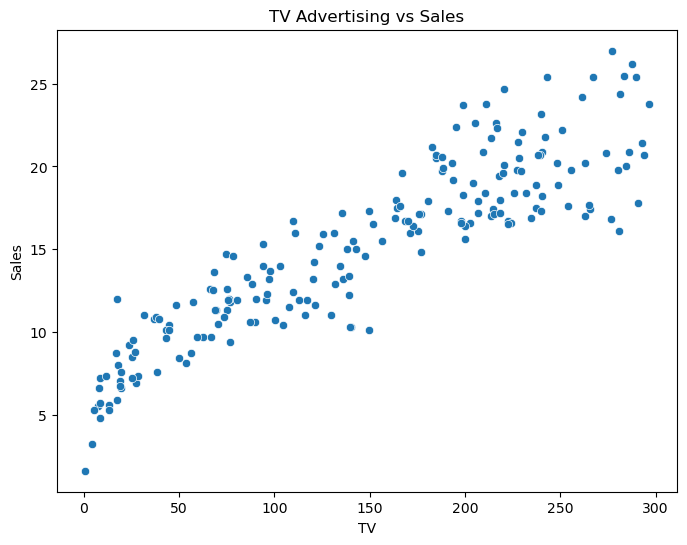

In [8]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='TV', y='Sales', data=df)
plt.title('TV Advertising vs Sales')
plt.show()

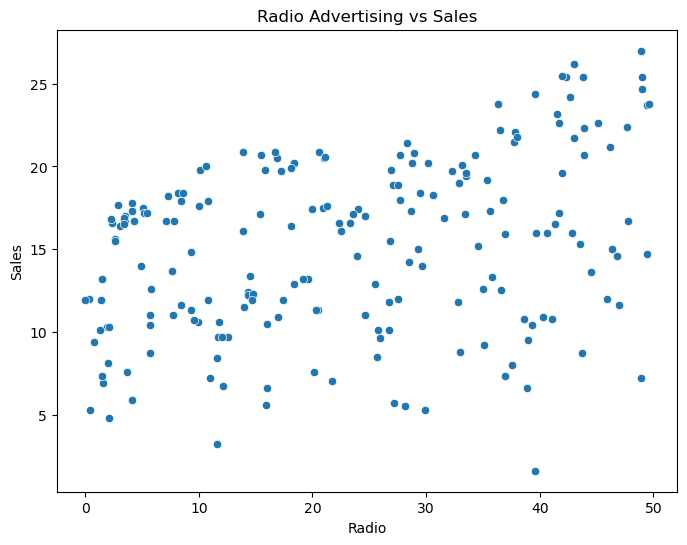

In [9]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='Radio', y='Sales', data=df)
plt.title('Radio Advertising vs Sales')
plt.show()

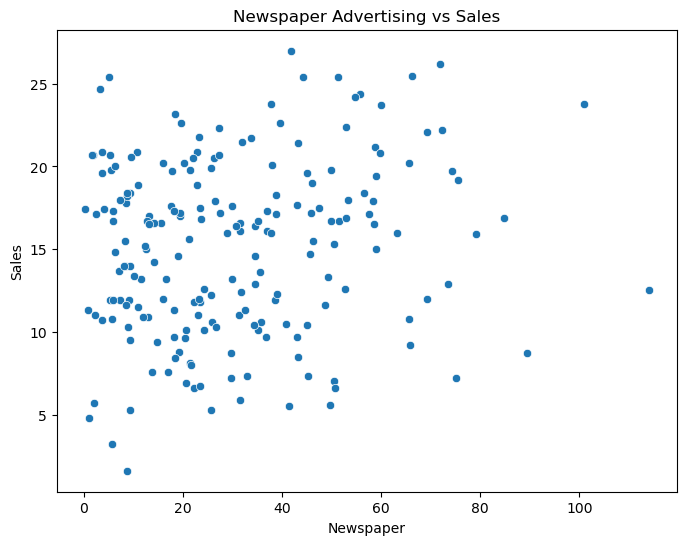

In [10]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='Newspaper', y='Sales', data=df)
plt.title('Newspaper Advertising vs Sales')
plt.show()

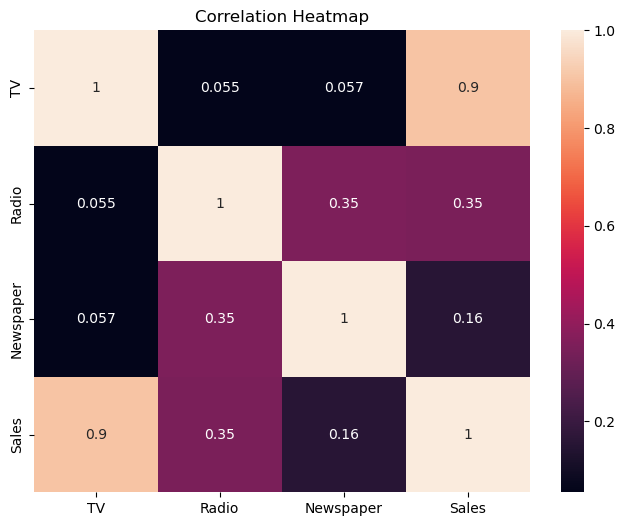

In [11]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

## Feature Selection

Separating input features and target variable.

In [13]:
X = df.drop('Sales', axis=1)
y = df['Sales']

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (200, 3)
Target Shape: (200,)


## Train-Test Split

Dividing the dataset into training and testing sets.

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (160, 3)
Testing Data: (40, 3)


## Model Training

Training a Random Forest Regressor to predict sales based on advertising expenditure.

In [15]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Sales Prediction

Using the trained model to predict sales on the test dataset.

In [16]:
y_pred = model.predict(X_test)

## Model Evaluation

Evaluating the performance of the model using:

In [17]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)
print("R2 Score:", r2)

Mean Absolute Error: 0.9179999999999993
Root Mean Squared Error: 1.1989298770153327
R2 Score: 0.9534827934927883


## Actual vs Predicted S ales

Comparing actual sales values with predicted sales values. 

In [18]:
comparison = pd.DataFrame({
    'Actual Sales': y_test,
    'Predicted Sales': y_pred
})

comparison.head(10)

,Actual Sales,Predicted Sales
95,16.9,17.299
15,22.4,22.482
30,21.4,19.770
158,7.3,6.784
128,24.7,22.961
115,12.6,13.471
69,22.3,22.595
170,8.4,9.579
174,16.5,16.887
45,16.1,16.793


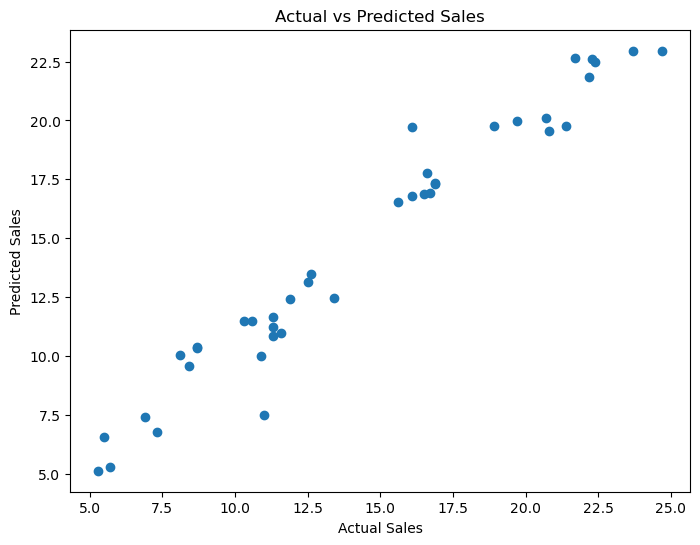

In [19]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

plt.show()

## Feature Importance

Analyzing which advertising channels contribute most to sales prediction.

In [20]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

     Feature  Importance
0         TV    0.845355
1      Radio    0.136642
2  Newspaper    0.018003


## Saving the Model

Saving the trained machine learning model for future use.

In [21]:
import joblib

joblib.dump(model, "sales_prediction_model.pkl")

['sales_prediction_model.pkl']

## Conclusion

A Random Forest Regression model was successfully developed to predict sales using advertising expenditure data.

The model demonstrates how machine learning can help businesses estimate sales outcomes based on marketing investments across TV, Radio, and Newspaper channels.